In [1]:
import numpy as np
from tensorflow.keras.models import load_model
from scipy.stats import boxcox
from scipy.special import  inv_boxcox
from sklearn.preprocessing import RobustScaler
from deap import base, creator, tools, algorithms
import random
import matplotlib.pyplot as plt
import pandas as pd





In [2]:
from tensorflow.keras.models import load_model
from tensorflow.keras.metrics import MeanSquaredError

model = load_model(
    "C:\\Users\\Administrateur\\Desktop\\code_stage_v2\\best_RN_Ra_dens_model.h5",
    custom_objects={'mse': MeanSquaredError()}
)

    
data=pd.read_excel("Data\data_combined_synth_Ra_density_86.xlsx")
data=data.dropna()
data=data[['p','v','h','t','Ra','density']]
X=data[['p','v','h', 't']]
y=data[['Ra','density']]


In [3]:

Ra = y['Ra'].values.flatten()
density = y['density'].values.flatten()


scaler_X = RobustScaler()
X_scaled = scaler_X.fit_transform(X)

Ra_shifted = Ra + 1e-5
Ra_boxcox, lambda_ra = boxcox(Ra_shifted)
scaler_Ra = RobustScaler()
Ra_scaled = scaler_Ra.fit_transform(Ra_boxcox.reshape(-1, 1))

scaler_density = RobustScaler()
density_scaled = scaler_density.fit_transform(density.reshape(-1, 1))










In [4]:

def predict_objectives(params):
    try:
        params = np.array(params).reshape(1, -1)
        params = np.clip(params, LOW, UP)  
        x_scaled = scaler_X.transform(params)
        y_scaled = model.predict(x_scaled)

        ra_pred_scaled = y_scaled[:, 0]
        density_pred_scaled = y_scaled[:, 1]

        ra_boxcox = scaler_Ra.inverse_transform(ra_pred_scaled.reshape(-1, 1)).flatten()
        ra = inv_boxcox(ra_boxcox, lambda_ra)[0]

        density = scaler_density.inverse_transform(density_pred_scaled.reshape(-1, 1)).flatten()[0]

        # Distance aux cibles
        obj1 = abs(ra - TARGET_RA)
        obj2 = abs(density - TARGET_DENSITY)

        return obj1, obj2

    except Exception as e:
        print(f"Erreur avec params={params} : {e}")
        return 1e6, 1e6


In [5]:

def predict_values(params):
    params = np.array(params).reshape(1, -1)
    params = np.clip(params, LOW, UP)
    x_scaled = scaler_X.transform(params)
    y_scaled = model.predict(x_scaled)

    ra_pred_scaled = y_scaled[:, 0]
    density_pred_scaled = y_scaled[:, 1]

    ra_boxcox = scaler_Ra.inverse_transform(ra_pred_scaled.reshape(-1, 1)).flatten()
    ra = inv_boxcox(ra_boxcox, lambda_ra)[0]

    density = scaler_density.inverse_transform(density_pred_scaled.reshape(-1, 1)).flatten()[0]

    return ra, density


In [6]:

param_bounds = {
    "p": (60, 370),
    "v": (250, 1300),
    "h": (50, 120),
    "t": (20, 50)
}
param_keys = list(param_bounds.keys())
LOW = [param_bounds[k][0] for k in param_keys]
UP = [param_bounds[k][1] for k in param_keys]

In [7]:
import warnings
warnings.filterwarnings(action='ignore', message='X does not have valid feature names*')


In [38]:
TARGET_RA = 7
TARGET_DENSITY = 96


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 195ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 50ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 57ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 44ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 65ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 63ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 60ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 67ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 43ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 56ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 53ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 58ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 53ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 65ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 61ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 63ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 51ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 58ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 59ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 57ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 52ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 54ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 65ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 52ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 53ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 57ms/step
1/1 ━━━━━━━

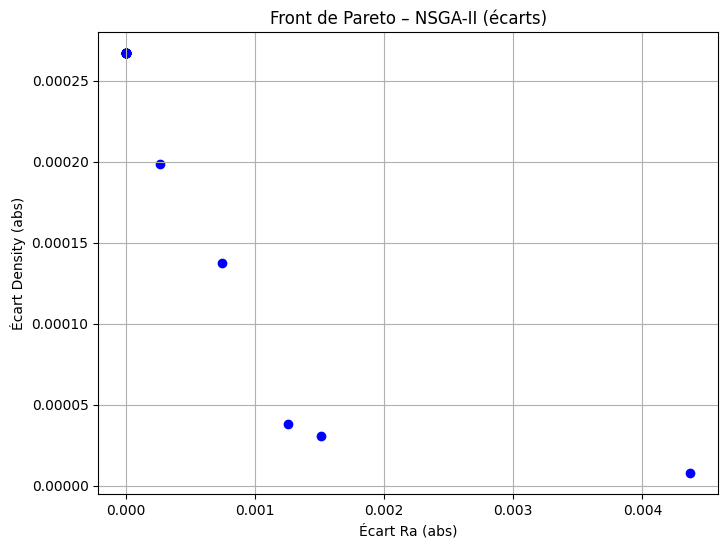

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 43ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 51ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 50ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 58ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 57ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 49ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 57ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 56ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 52ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 51ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 49ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 62ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 59ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 52ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 58ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 48ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 59ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 61ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 49ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 55ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 48ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 61ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 63ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 53ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 51ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 50ms/step
1/1 ━━━━━━━━

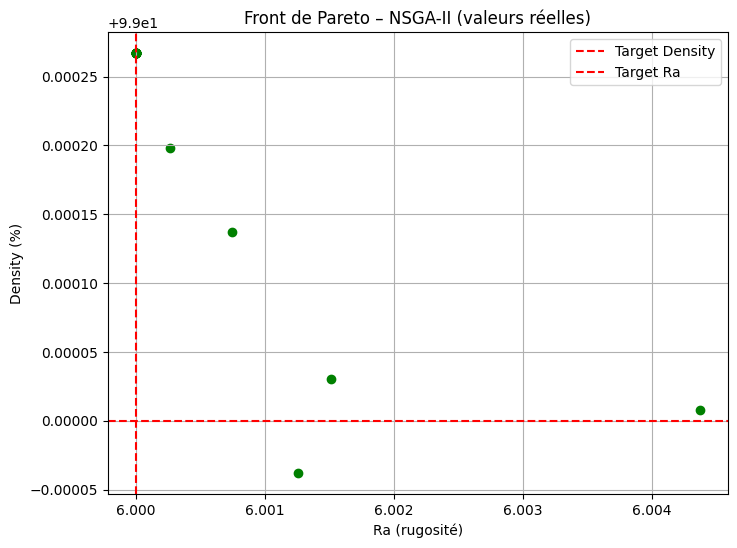

In [8]:
TARGET_RA = 6
TARGET_DENSITY = 99



# Création du type FitnessMulti pour minimiser 2 objectifs
if not hasattr(creator, "FitnessMulti"):
    creator.create("FitnessMulti", base.Fitness, weights=(-1.0, -1.0))  # Minimiser obj1 et obj2
if not hasattr(creator, "Individual"):
    creator.create("Individual", list, fitness=creator.FitnessMulti)

# Génération aléatoire d'un individu dans les bornes
def generate_individual():
    return [random.uniform(l, u) for l, u in zip(LOW, UP)]

# Toolbox DEAP
toolbox = base.Toolbox()
toolbox.register("individual", tools.initIterate, creator.Individual, generate_individual)
toolbox.register("population", tools.initRepeat, list, toolbox.individual)
toolbox.register("evaluate", predict_objectives)
toolbox.register("mate", tools.cxBlend, alpha=0.5)
toolbox.register("mutate", tools.mutPolynomialBounded, eta=10, low=LOW, up=UP, indpb=0.2)
toolbox.register("select", tools.selNSGA2)

# Paramètres évolution
population = toolbox.population(n=500)
NGEN = 100
MU = 50
CXPB = 0.9
MUTPB = 0.2

# Évaluation initiale
for ind in population:
    ind.fitness.values = toolbox.evaluate(ind)

# Boucle évolution
for gen in range(NGEN):
    offspring = algorithms.varAnd(population, toolbox, cxpb=CXPB, mutpb=MUTPB)
    
    for ind in offspring:
        ind.fitness.values = toolbox.evaluate(ind)
    
    population = toolbox.select(population + offspring, MU)

# Récupération du front de Pareto
pareto_front = tools.sortNondominated(population, k=len(population), first_front_only=True)[0]

# Réévaluation au cas où
for ind in pareto_front:
    if not ind.fitness.valid or len(ind.fitness.values) != 2:
        ind.fitness.values = toolbox.evaluate(ind)

print("Solutions Pareto optimales (avec valeurs réelles et écarts) :")
for ind in pareto_front:
    ra_val, density_val = predict_values(ind)
    print(f"Params = {dict(zip(param_keys, ind))}, Ra = {ra_val:.3f}, Density = {density_val:.3f}, Écarts = {ind.fitness.values}")

# Pour tracer : on trace les écarts (fitness) mais on peut aussi tracer les vraies valeurs
ras = [abs(predict_values(ind)[0] - TARGET_RA) for ind in pareto_front]
densities = [abs(predict_values(ind)[1] - TARGET_DENSITY) for ind in pareto_front]

plt.figure(figsize=(8, 6))
plt.scatter(ras, densities, c='blue')
plt.xlabel("Écart Ra (abs)")
plt.ylabel("Écart Density (abs)")
plt.title("Front de Pareto – NSGA-II (écarts)")
plt.grid(True)
plt.show()

# Optionnel : Tracer les vraies valeurs Ra vs Density
real_ras = [predict_values(ind)[0] for ind in pareto_front]
real_densities = [predict_values(ind)[1] for ind in pareto_front]

plt.figure(figsize=(8, 6))
plt.scatter(real_ras, real_densities, c='green')
plt.axhline(y=TARGET_DENSITY, color='r', linestyle='--', label='Target Density')
plt.axvline(x=TARGET_RA, color='r', linestyle='--', label='Target Ra')
plt.xlabel("Ra (rugosité)")
plt.ylabel("Density (%)")
plt.title("Front de Pareto – NSGA-II (valeurs réelles)")
plt.legend()
plt.grid(True)
plt.show()


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 54ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 46ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 45ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 53ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 49ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 49ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 61ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 48ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 70ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 57ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 50ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 52ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 50ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 58ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 50ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 51ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 56ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 48ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 49ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 50ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 49ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 65ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 49ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 53ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 62ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 49ms/step
1/1 ━━━━━━━━

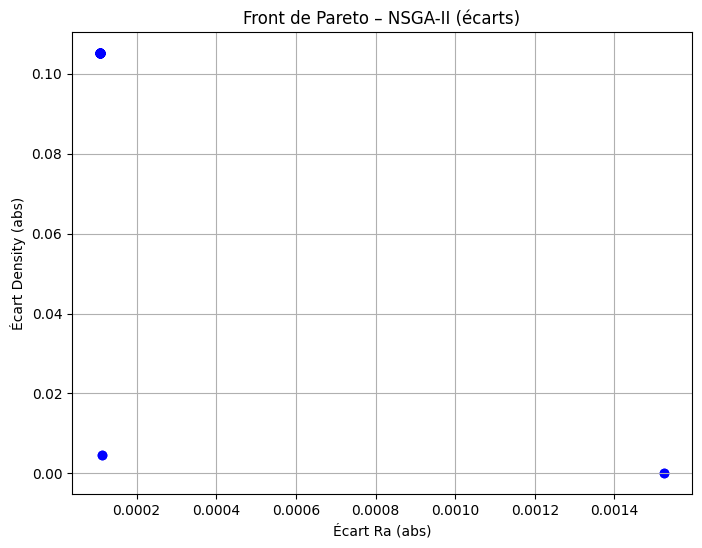

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 60ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 51ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 50ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 49ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 53ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 50ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 62ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 49ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 51ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 53ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 50ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 51ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 61ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 62ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 51ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 58ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 58ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 55ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 53ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 53ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 47ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 60ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 50ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 50ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 61ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 58ms/step
1/1 ━━━━━━━━

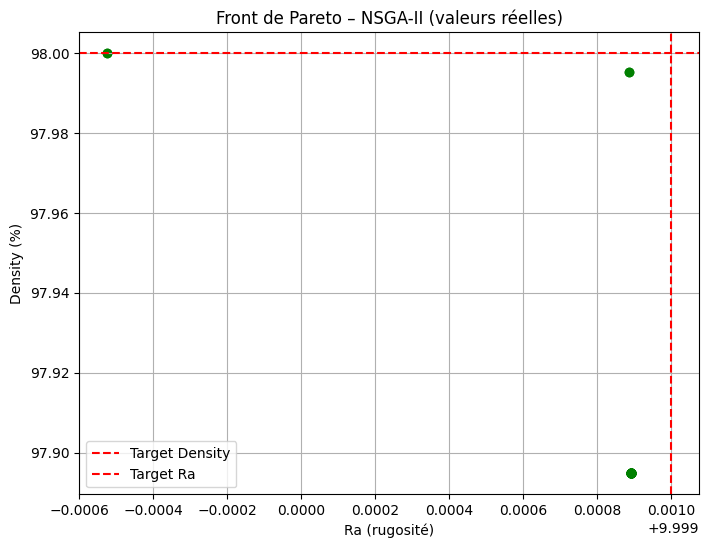

In [9]:
TARGET_RA = 10
TARGET_DENSITY = 98



# Création du type FitnessMulti pour minimiser 2 objectifs
if not hasattr(creator, "FitnessMulti"):
    creator.create("FitnessMulti", base.Fitness, weights=(-1.0, -1.0))  # Minimiser obj1 et obj2
if not hasattr(creator, "Individual"):
    creator.create("Individual", list, fitness=creator.FitnessMulti)

# Génération aléatoire d'un individu dans les bornes
def generate_individual():
    return [random.uniform(l, u) for l, u in zip(LOW, UP)]

# Toolbox DEAP
toolbox = base.Toolbox()
toolbox.register("individual", tools.initIterate, creator.Individual, generate_individual)
toolbox.register("population", tools.initRepeat, list, toolbox.individual)
toolbox.register("evaluate", predict_objectives)
toolbox.register("mate", tools.cxBlend, alpha=0.5)
toolbox.register("mutate", tools.mutPolynomialBounded, eta=10, low=LOW, up=UP, indpb=0.2)
toolbox.register("select", tools.selNSGA2)

# Paramètres évolution
population = toolbox.population(n=500)
NGEN = 100
MU = 50
CXPB = 0.9
MUTPB = 0.2

# Évaluation initiale
for ind in population:
    ind.fitness.values = toolbox.evaluate(ind)

# Boucle évolution
for gen in range(NGEN):
    offspring = algorithms.varAnd(population, toolbox, cxpb=CXPB, mutpb=MUTPB)
    
    for ind in offspring:
        ind.fitness.values = toolbox.evaluate(ind)
    
    population = toolbox.select(population + offspring, MU)

# Récupération du front de Pareto
pareto_front = tools.sortNondominated(population, k=len(population), first_front_only=True)[0]

# Réévaluation au cas où
for ind in pareto_front:
    if not ind.fitness.valid or len(ind.fitness.values) != 2:
        ind.fitness.values = toolbox.evaluate(ind)

print("Solutions Pareto optimales (avec valeurs réelles et écarts) :")
for ind in pareto_front:
    ra_val, density_val = predict_values(ind)
    print(f"Params = {dict(zip(param_keys, ind))}, Ra = {ra_val:.3f}, Density = {density_val:.3f}, Écarts = {ind.fitness.values}")

# Pour tracer : on trace les écarts (fitness) mais on peut aussi tracer les vraies valeurs
ras = [abs(predict_values(ind)[0] - TARGET_RA) for ind in pareto_front]
densities = [abs(predict_values(ind)[1] - TARGET_DENSITY) for ind in pareto_front]

plt.figure(figsize=(8, 6))
plt.scatter(ras, densities, c='blue')
plt.xlabel("Écart Ra (abs)")
plt.ylabel("Écart Density (abs)")
plt.title("Front de Pareto – NSGA-II (écarts)")
plt.grid(True)
plt.show()

# Optionnel : Tracer les vraies valeurs Ra vs Density
real_ras = [predict_values(ind)[0] for ind in pareto_front]
real_densities = [predict_values(ind)[1] for ind in pareto_front]

plt.figure(figsize=(8, 6))
plt.scatter(real_ras, real_densities, c='green')
plt.axhline(y=TARGET_DENSITY, color='r', linestyle='--', label='Target Density')
plt.axvline(x=TARGET_RA, color='r', linestyle='--', label='Target Ra')
plt.xlabel("Ra (rugosité)")
plt.ylabel("Density (%)")
plt.title("Front de Pareto – NSGA-II (valeurs réelles)")
plt.legend()
plt.grid(True)
plt.show()


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 48ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 66ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 71ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 48ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 61ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 52ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 51ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 55ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 62ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 50ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 51ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 50ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 50ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 50ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 53ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 49ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 52ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 53ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 62ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 52ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 59ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 49ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 53ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 60ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 54ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 49ms/step
1/1 ━━━━━━━━

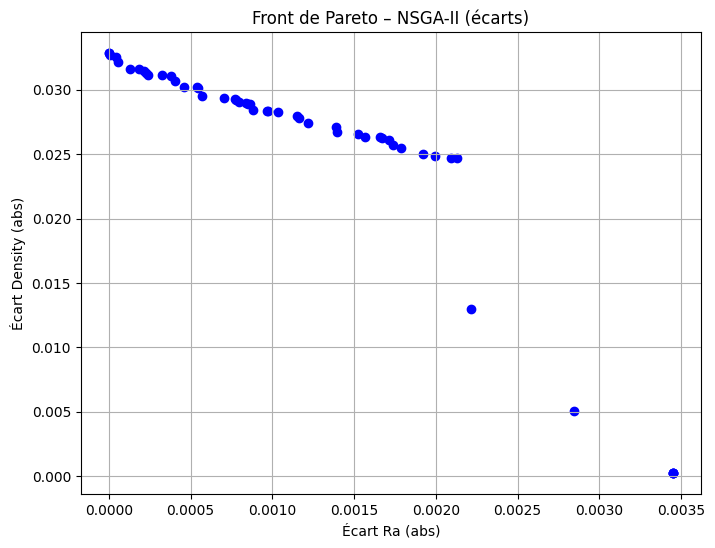

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 49ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 58ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 63ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 52ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 50ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 57ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 49ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 52ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 50ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 53ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 57ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 64ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 52ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 50ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 51ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 59ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 59ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 62ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 51ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 63ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 50ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 49ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 50ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 49ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 58ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 50ms/step
1/1 ━━━━━━━━

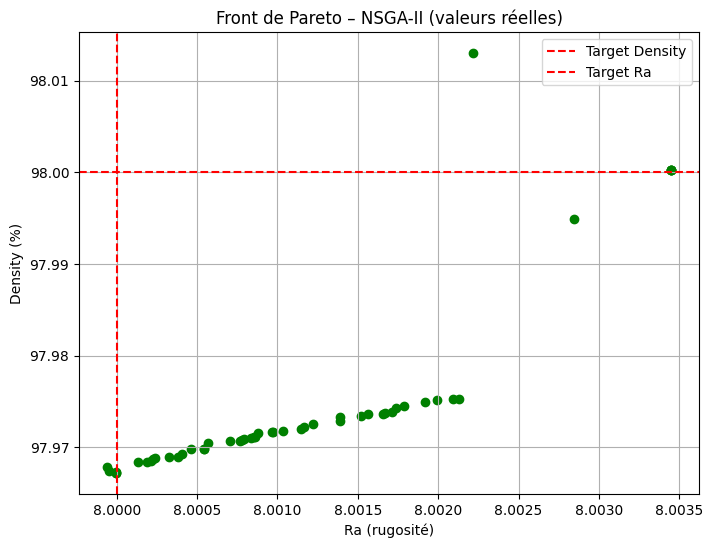

In [ ]:
TARGET_RA = 8.0
TARGET_DENSITY = 98.0



# Création du type FitnessMulti pour minimiser 2 objectifs
if not hasattr(creator, "FitnessMulti"):
    creator.create("FitnessMulti", base.Fitness, weights=(-1.0, -1.0))  # Minimiser obj1 et obj2
if not hasattr(creator, "Individual"):
    creator.create("Individual", list, fitness=creator.FitnessMulti)

# Génération aléatoire d'un individu dans les bornes
def generate_individual():
    return [random.uniform(l, u) for l, u in zip(LOW, UP)]

# Toolbox DEAP
toolbox = base.Toolbox()
toolbox.register("individual", tools.initIterate, creator.Individual, generate_individual)
toolbox.register("population", tools.initRepeat, list, toolbox.individual)
toolbox.register("evaluate", predict_objectives)
toolbox.register("mate", tools.cxBlend, alpha=0.5)
toolbox.register("mutate", tools.mutPolynomialBounded, eta=10, low=LOW, up=UP, indpb=0.2)
toolbox.register("select", tools.selNSGA2)

# Paramètres évolution
population = toolbox.population(n=500)
NGEN = 100
MU = 50
CXPB = 0.9
MUTPB = 0.2

# Évaluation initiale
for ind in population:
    ind.fitness.values = toolbox.evaluate(ind)

# Boucle évolution
for gen in range(NGEN):
    offspring = algorithms.varAnd(population, toolbox, cxpb=CXPB, mutpb=MUTPB)
    
    for ind in offspring:
        ind.fitness.values = toolbox.evaluate(ind)
    
    population = toolbox.select(population + offspring, MU)

# Récupération du front de Pareto
pareto_front = tools.sortNondominated(population, k=len(population), first_front_only=True)[0]

# Réévaluation au cas où
for ind in pareto_front:
    if not ind.fitness.valid or len(ind.fitness.values) != 2:
        ind.fitness.values = toolbox.evaluate(ind)

print("Solutions Pareto optimales (avec valeurs réelles et écarts) :")
for ind in pareto_front:
    ra_val, density_val = predict_values(ind)
    print(f"Params = {dict(zip(param_keys, ind))}, Ra = {ra_val:.3f}, Density = {density_val:.3f}, Écarts = {ind.fitness.values}")

# Pour tracer : on trace les écarts (fitness) mais on peut aussi tracer les vraies valeurs
ras = [abs(predict_values(ind)[0] - TARGET_RA) for ind in pareto_front]
densities = [abs(predict_values(ind)[1] - TARGET_DENSITY) for ind in pareto_front]

plt.figure(figsize=(8, 6))
plt.scatter(ras, densities, c='blue')
plt.xlabel("Écart Ra (abs)")
plt.ylabel("Écart Density (abs)")
plt.title("Front de Pareto – NSGA-II (écarts)")
plt.grid(True)
plt.show()

# Optionnel : Tracer les vraies valeurs Ra vs Density
real_ras = [predict_values(ind)[0] for ind in pareto_front]
real_densities = [predict_values(ind)[1] for ind in pareto_front]

plt.figure(figsize=(8, 6))
plt.scatter(real_ras, real_densities, c='green')
plt.axhline(y=TARGET_DENSITY, color='r', linestyle='--', label='Target Density')
plt.axvline(x=TARGET_RA, color='r', linestyle='--', label='Target Ra')
plt.xlabel("Ra (rugosité)")
plt.ylabel("Density (%)")
plt.title("Front de Pareto – NSGA-II (valeurs réelles)")
plt.legend()
plt.grid(True)
plt.show()


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 49ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 54ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 56ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 52ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 65ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 63ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 60ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 50ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 57ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 54ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 65ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 49ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 60ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 51ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 59ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 59ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 59ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 52ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 53ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 58ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 61ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 54ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 50ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 62ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 55ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 43ms/step
1/1 ━━━━━━━━

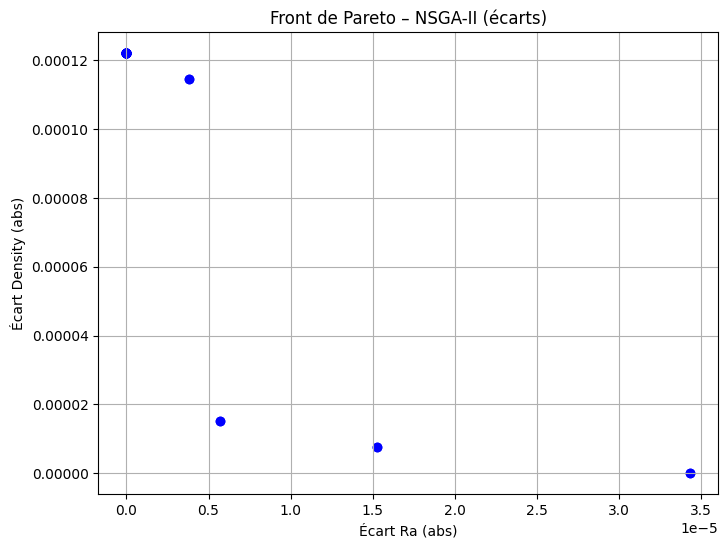

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 48ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 58ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 46ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 49ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 58ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 60ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 59ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 52ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 56ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 62ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 50ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 63ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 48ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 50ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 64ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 52ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 50ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 52ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 65ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 51ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 59ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 61ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 56ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 57ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 49ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 60ms/step
1/1 ━━━━━━━━

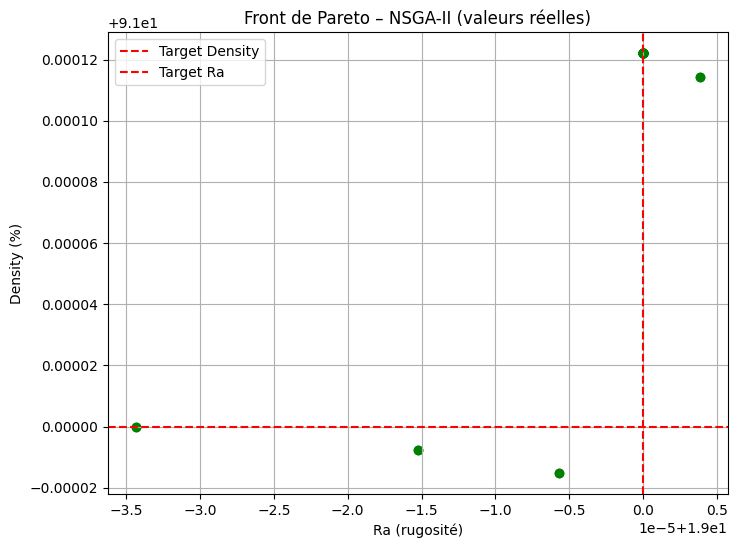

In [11]:
TARGET_RA = 19
TARGET_DENSITY = 91.0



# Création du type FitnessMulti pour minimiser 2 objectifs
if not hasattr(creator, "FitnessMulti"):
    creator.create("FitnessMulti", base.Fitness, weights=(-1.0, -1.0))  # Minimiser obj1 et obj2
if not hasattr(creator, "Individual"):
    creator.create("Individual", list, fitness=creator.FitnessMulti)

# Génération aléatoire d'un individu dans les bornes
def generate_individual():
    return [random.uniform(l, u) for l, u in zip(LOW, UP)]

# Toolbox DEAP
toolbox = base.Toolbox()
toolbox.register("individual", tools.initIterate, creator.Individual, generate_individual)
toolbox.register("population", tools.initRepeat, list, toolbox.individual)
toolbox.register("evaluate", predict_objectives)
toolbox.register("mate", tools.cxBlend, alpha=0.5)
toolbox.register("mutate", tools.mutPolynomialBounded, eta=10, low=LOW, up=UP, indpb=0.2)
toolbox.register("select", tools.selNSGA2)

# Paramètres évolution
population = toolbox.population(n=500)
NGEN = 100
MU = 50
CXPB = 0.9
MUTPB = 0.2

# Évaluation initiale
for ind in population:
    ind.fitness.values = toolbox.evaluate(ind)

# Boucle évolution
for gen in range(NGEN):
    offspring = algorithms.varAnd(population, toolbox, cxpb=CXPB, mutpb=MUTPB)
    
    for ind in offspring:
        ind.fitness.values = toolbox.evaluate(ind)
    
    population = toolbox.select(population + offspring, MU)

# Récupération du front de Pareto
pareto_front = tools.sortNondominated(population, k=len(population), first_front_only=True)[0]

# Réévaluation au cas où
for ind in pareto_front:
    if not ind.fitness.valid or len(ind.fitness.values) != 2:
        ind.fitness.values = toolbox.evaluate(ind)

print("Solutions Pareto optimales (avec valeurs réelles et écarts) :")
for ind in pareto_front:
    ra_val, density_val = predict_values(ind)
    print(f"Params = {dict(zip(param_keys, ind))}, Ra = {ra_val:.3f}, Density = {density_val:.3f}, Écarts = {ind.fitness.values}")

# Pour tracer : on trace les écarts (fitness) mais on peut aussi tracer les vraies valeurs
ras = [abs(predict_values(ind)[0] - TARGET_RA) for ind in pareto_front]
densities = [abs(predict_values(ind)[1] - TARGET_DENSITY) for ind in pareto_front]

plt.figure(figsize=(8, 6))
plt.scatter(ras, densities, c='blue')
plt.xlabel("Écart Ra (abs)")
plt.ylabel("Écart Density (abs)")
plt.title("Front de Pareto – NSGA-II (écarts)")
plt.grid(True)
plt.show()

# Optionnel : Tracer les vraies valeurs Ra vs Density
real_ras = [predict_values(ind)[0] for ind in pareto_front]
real_densities = [predict_values(ind)[1] for ind in pareto_front]

plt.figure(figsize=(8, 6))
plt.scatter(real_ras, real_densities, c='green')
plt.axhline(y=TARGET_DENSITY, color='r', linestyle='--', label='Target Density')
plt.axvline(x=TARGET_RA, color='r', linestyle='--', label='Target Ra')
plt.xlabel("Ra (rugosité)")
plt.ylabel("Density (%)")
plt.title("Front de Pareto – NSGA-II (valeurs réelles)")
plt.legend()
plt.grid(True)
plt.show()


In [ ]:
 RA= 5 et density = 99.5                 249.87 & 889.07 & 110.07 & 42.22 & 5.000 & 99.527 & 0.000005 & 0.0270 \\
249.87 & 884.69 & 111.59 & 42.46 & 5.002 & 99.505 & 0.0021   & 0.0050 \\  """"""  Ra=12 density =89     Params = {'p': 86.32695555081848, 'v': 437.83388118164, 'h': 60.484218065943885, 't': 38.45250577621547}, Ra = 12.000, Density = 88.963, Écarts = (3.528594970703125e-05, 0.03707122802734375) """" Ra=9     density=95    Params = {'p': 308.13145930270196, 'v': 477.94515254084365, 'h': 89.2517989506207, 't': 33.040497186672376}, Ra = 9.000, Density = 95.000, Écarts = (4.9591064453125e-05, 0.0) 

Params = {'p': 308.12988567706896, 'v': 477.94534313841893, 'h': 89.25037230417422, 't': 33.040492163687915}, Ra = 9.000, Density = 95.000, Écarts = (1.33514404296875e-05, 1.52587890625e-05)   """ Ra= 7  density =96           

Params = {'p': 290.48732391285336, 'v': 930.1780048212221, 'h': 71.6451832586353, 't': 32.644497941765}, Ra = 7.000, Density = 96.000, Écarts = (0.0, 0.00028228759765625)

Params = {'p': 290.4881252637608, 'v': 930.1777916291815, 'h': 71.6435754463498, 't': 32.64452957444916}, Ra = 7.000, Density = 96.000, Écarts = (5.245208740234375e-06, 1.52587890625e-05)

In [ ]:
from scipy.optimize import differential_evolution
TARGET_RA = 6
TARGET_DENSITY = 99



ALPHA = 1.0  
BETA = 1.0   
def inv_boxcox(y, lmbda):
    if lmbda == 0:
        return np.exp(y)
    else:
        return np.power(y * lmbda + 1, 1 / lmbda)


def predict_objectives(params):
    try:
        params = np.array(params).reshape(1, -1)
        params = np.clip(params, LOW, UP)
        x_scaled = scaler_X.transform(params)
        y_scaled = model.predict(x_scaled, verbose=0)

        ra_pred_scaled = y_scaled[:, 0]
        density_pred_scaled = y_scaled[:, 1]

        ra_boxcox = scaler_Ra.inverse_transform(ra_pred_scaled.reshape(-1, 1)).flatten()
        ra = inv_boxcox(ra_boxcox, lambda_ra)[0]
        density = scaler_density.inverse_transform(density_pred_scaled.reshape(-1, 1)).flatten()[0]

        return ra, density
    except Exception as e:
        print(f"Erreur de prédiction pour params={params} : {e}")
        return 1e6, 1e6


def objective(params):
    ra, density = predict_objectives(params)
    return ALPHA * (ra - TARGET_RA)**2 + BETA * (density - TARGET_DENSITY)**2


result = differential_evolution(
    objective,
    bounds=list(zip(LOW, UP)),
    strategy='best1bin',
    popsize=100,
    mutation=(0.5, 1),
    recombination=0.7,
    seed=42,
    maxiter=50,
    polish=True
)


optimal_params = result.x
ra_opt, density_opt = predict_objectives(optimal_params)
optimal_params_dict = dict(zip(param_keys, optimal_params))

print("\n--- Résultat Optimal ---")
print("Paramètres optimaux :", optimal_params_dict)
print(f"Ra prédite       : {ra_opt:.3f}")
print(f"Density prédite  : {density_opt:.3f}")



--- Résultat Optimal ---
Paramètres optimaux : {'p': 261.55760297600136, 'v': 1078.7248855163955, 'h': 95.77016674776772, 't': 45.87144799960485}
Ra prédite       : 6.000
Density prédite  : 99.002


In [ ]:
from scipy.optimize import differential_evolution
TARGET_RA =10
TARGET_DENSITY = 98



ALPHA = 1.0  
BETA = 1.0   
def inv_boxcox(y, lmbda):
    if lmbda == 0:
        return np.exp(y)
    else:
        return np.power(y * lmbda + 1, 1 / lmbda)


def predict_objectives(params):
    try:
        params = np.array(params).reshape(1, -1)
        params = np.clip(params, LOW, UP)
        x_scaled = scaler_X.transform(params)
        y_scaled = model.predict(x_scaled, verbose=0)

        ra_pred_scaled = y_scaled[:, 0]
        density_pred_scaled = y_scaled[:, 1]

        ra_boxcox = scaler_Ra.inverse_transform(ra_pred_scaled.reshape(-1, 1)).flatten()
        ra = inv_boxcox(ra_boxcox, lambda_ra)[0]
        density = scaler_density.inverse_transform(density_pred_scaled.reshape(-1, 1)).flatten()[0]

        return ra, density
    except Exception as e:
        print(f"Erreur de prédiction pour params={params} : {e}")
        return 1e6, 1e6


def objective(params):
    ra, density = predict_objectives(params)
    return ALPHA * (ra - TARGET_RA)**2 + BETA * (density - TARGET_DENSITY)**2


result = differential_evolution(
    objective,
    bounds=list(zip(LOW, UP)),
    strategy='best1bin',
    popsize=100,
    mutation=(0.5, 1),
    recombination=0.7,
    seed=42,
    maxiter=50,
    polish=True
)


optimal_params = result.x
ra_opt, density_opt = predict_objectives(optimal_params)
optimal_params_dict = dict(zip(param_keys, optimal_params))

print("\n--- Résultat Optimal ---")
print("Paramètres optimaux :", optimal_params_dict)
print(f"Ra prédite       : {ra_opt:.3f}")
print(f"Density prédite  : {density_opt:.3f}")



--- Résultat Optimal ---
Paramètres optimaux : {'p': 253.00090617957204, 'v': 1146.4192335842508, 'h': 52.189603342204244, 't': 26.939034102148362}
Ra prédite       : 10.000
Density prédite  : 98.000


In [49]:
from scipy.optimize import differential_evolution
TARGET_RA = 8
TARGET_DENSITY = 98




ALPHA = 1.0  
BETA = 1.0   
def inv_boxcox(y, lmbda):
    if lmbda == 0:
        return np.exp(y)
    else:
        return np.power(y * lmbda + 1, 1 / lmbda)


def predict_objectives(params):
    try:
        params = np.array(params).reshape(1, -1)
        params = np.clip(params, LOW, UP)
        x_scaled = scaler_X.transform(params)
        y_scaled = model.predict(x_scaled, verbose=0)

        ra_pred_scaled = y_scaled[:, 0]
        density_pred_scaled = y_scaled[:, 1]

        ra_boxcox = scaler_Ra.inverse_transform(ra_pred_scaled.reshape(-1, 1)).flatten()
        ra = inv_boxcox(ra_boxcox, lambda_ra)[0]
        density = scaler_density.inverse_transform(density_pred_scaled.reshape(-1, 1)).flatten()[0]

        return ra, density
    except Exception as e:
        print(f"Erreur de prédiction pour params={params} : {e}")
        return 1e6, 1e6


def objective(params):
    ra, density = predict_objectives(params)
    return ALPHA * (ra - TARGET_RA)**2 + BETA * (density - TARGET_DENSITY)**2


result = differential_evolution(
    objective,
    bounds=list(zip(LOW, UP)),
    strategy='best1bin',
    popsize=100,
    mutation=(0.5, 1),
    recombination=0.7,
    seed=42,
    maxiter=50,
    polish=True
)


optimal_params = result.x
ra_opt, density_opt = predict_objectives(optimal_params)
optimal_params_dict = dict(zip(param_keys, optimal_params))

print("\n--- Résultat Optimal ---")
print("Paramètres optimaux :", optimal_params_dict)
print(f"Ra prédite       : {ra_opt:.3f}")
print(f"Density prédite  : {density_opt:.3f}")



--- Résultat Optimal ---
Paramètres optimaux : {'p': 137.24365008871598, 'v': 294.679037530104, 'h': 88.10348917710725, 't': 33.76572118301933}
Ra prédite       : 8.009
Density prédite  : 98.002


In [ ]:
from scipy.optimize import differential_evolution
TARGET_RA = 19
TARGET_DENSITY = 91




ALPHA = 1.0  
BETA = 1.0   
def inv_boxcox(y, lmbda):
    if lmbda == 0:
        return np.exp(y)
    else:
        return np.power(y * lmbda + 1, 1 / lmbda)


def predict_objectives(params):
    try:
        params = np.array(params).reshape(1, -1)
        params = np.clip(params, LOW, UP)
        x_scaled = scaler_X.transform(params)
        y_scaled = model.predict(x_scaled, verbose=0)

        ra_pred_scaled = y_scaled[:, 0]
        density_pred_scaled = y_scaled[:, 1]

        ra_boxcox = scaler_Ra.inverse_transform(ra_pred_scaled.reshape(-1, 1)).flatten()
        ra = inv_boxcox(ra_boxcox, lambda_ra)[0]
        density = scaler_density.inverse_transform(density_pred_scaled.reshape(-1, 1)).flatten()[0]

        return ra, density
    except Exception as e:
        print(f"Erreur de prédiction pour params={params} : {e}")
        return 1e6, 1e6


def objective(params):
    ra, density = predict_objectives(params)
    return ALPHA * (ra - TARGET_RA)**2 + BETA * (density - TARGET_DENSITY)**2


result = differential_evolution(
    objective,
    bounds=list(zip(LOW, UP)),
    strategy='best1bin',
    popsize=100,
    mutation=(0.5, 1),
    recombination=0.7,
    seed=42,
    maxiter=50,
    polish=True
)


optimal_params = result.x
ra_opt, density_opt = predict_objectives(optimal_params)
optimal_params_dict = dict(zip(param_keys, optimal_params))

print("\n--- Résultat Optimal ---")
print("Paramètres optimaux :", optimal_params_dict)
print(f"Ra prédite       : {ra_opt:.3f}")
print(f"Density prédite  : {density_opt:.3f}")



--- Résultat Optimal ---
Paramètres optimaux : {'p': 360.45173816531167, 'v': 668.5858332329865, 'h': 118.27316030847908, 't': 46.73492216752838}
Ra prédite       : 18.998
Density prédite  : 91.000
